In [54]:
import kwant
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import eig
from scipy.optimize import fmin
import os
from tqdm import tqdm
from joblib import Parallel, delayed
import matplotlib.patches as mpatches
from scipy.integrate import simpson  
from joblib import Parallel, delayed
import matplotlib.cm as cm
import matplotlib.colors as colors
import scipy.sparse as sp
import scipy.sparse.linalg as spla
import pandas as pd

In [62]:
#function
def gr_L_keni(T_l, A_l, tol=1e-16):
    N = T_l.shape[0]
    I = np.eye(N)

    A = np.block([
        [np.zeros((N, N)), I],
        [-T_l.conj().T, A_l]
    ])

    B = np.block([
        [I, np.zeros((N, N))],
        [np.zeros((N, N)), T_l]
    ])

    eigvals, eigvecs = eig(A, B)

    lambdas = []
    modes = []

    for i, lam in enumerate(eigvals):
        if np.abs(lam) < 1 - tol:   # 衰减模式
            x = eigvecs[:N, i]
            x /= np.linalg.norm(x)
            lambdas.append(lam)
            modes.append(x)

    X = np.column_stack(modes)
    Lambda = np.diag(lambdas)
    #print(Lambda.shape,X.shape)
    F = X @ Lambda @ np.linalg.inv(X)

    gL = np.linalg.inv(A_l - T_l @ F)

    return gL

def gr_L(T_l, A_l, check_tol=1e-6):

    N = T_l.shape[0]
    I = np.eye(N)
    Tmat = np.block([
        [np.linalg.inv(T_l) @ A_l, -np.linalg.inv(T_l) @ T_l.conj().T],
        [I, np.zeros((N, N))]
    ])

    eigvals, eigvecs = eig(Tmat)


    idx = np.argsort(np.abs(eigvals))
    eigvals = eigvals[idx]
    eigvecs = eigvecs[:, idx]

    lambdas = eigvals[:N]
    vecs = eigvecs[:, :N]

    S1 = vecs[:N, :] 
    S2 = vecs[N:, :]  

    gL = np.linalg.inv(A_l - T_l @ S1 @ np.linalg.inv(S2))
    #check = (A_l - T_l @ gL @ T_l.conj().T) @ gL - I
    #max_err = np.max(np.abs(check))

    return gL

def zinengr_L(T_LD_wei ,gr_L_wei):
    return T_LD_wei.conj().T @ gr_L_wei @ T_LD_wei

def Gr_DD(H_q_list, H_l, H_r, T_21, T_LD, T_l, T_RD, T_r, xshumu, E, eta=1e-6):

    d_device = H_q_list[0].shape[0]  
    d_lead = H_l.shape[0]            
    
    I_device = np.eye(d_device, dtype=complex)
    Z = np.zeros((d_device, d_device), dtype=complex)

    EI_lead = (E + 1j*eta) * np.eye(d_lead, dtype=complex)
    EI_device = (E + 1j*eta) * I_device

    A_l = EI_lead - H_l
    gcl = gr_L_keni(T_l, A_l)
    Sigma_L = zinengr_L(T_LD, gcl)


    A_r = EI_lead - H_r
    gcr = gr_L_keni(T_r, A_r)
    Sigma_R = zinengr_L(T_RD, gcr)

    A_DD = [[Z.copy() for _ in range(xshumu)] for _ in range(xshumu)]

    for i in range(xshumu):
 
        H_q_i = H_q_list[i]

        if i == 0:
            A_DD[i][i] = EI_device - H_q_i - Sigma_L
        elif i == xshumu-1:
            A_DD[i][i] = EI_device - H_q_i - Sigma_R
        else:
            A_DD[i][i] = EI_device - H_q_i

        # 加上层间跃迁
        if i < xshumu-1:
            A_DD[i][i+1] = -T_21
        if i > 0:
            A_DD[i][i-1] = -T_21.conj().T

    A_DD = np.block(A_DD)

    G_DD_r = np.linalg.inv(A_DD)
    
    return G_DD_r, Sigma_R, Sigma_L

def Gr_DD_2(H_q_list, H_l, H_r, T_21, T_LD, T_l, T_RD, T_r, xshumu, E, eta=1e-6):
    N = xshumu
    
    d_device = H_q_list[0].shape[0]  
    d_lead = H_l.shape[0]            
    
    I_device = np.eye(d_device, dtype=complex)
    

    EI_lead = (E + 1j*eta) * np.eye(d_lead, dtype=complex)
    EI_device = (E + 1j*eta) * I_device

    A_l = EI_lead - H_l
    gcl = gr_L_keni(T_l, A_l)
    Sigma_L = zinengr_L(T_LD, gcl)

    A_r = EI_lead - H_r
    gcr = gr_L_keni(T_r, A_r)
    Sigma_R = zinengr_L(T_RD, gcr)

    V = T_21
    V_dagger = V.conj().T
    
    # gL 数组存储从左向右扫描的局域有效格林函数
    gL = np.zeros((N, d_device, d_device), dtype=complex)
    
    # 1. 第 0 层 (最左侧)：包含本层哈密顿量和左电极自能
    gL[0] = np.linalg.inv(EI_device - H_q_list[0] - Sigma_L)
    
    # 2. 中间层：通过 Dyson 方程，把左侧所有层的物理效应折叠为本层的等效自能
    for n in range(1, N-1):
        Sigma_eff_L = V_dagger @ gL[n-1] @ V
        gL[n] = np.linalg.inv(EI_device - H_q_list[n] - Sigma_eff_L)
        
    # 3. 第 N-1 层 (最右侧)：包含左侧传播来的等效自能，以及真实的右电极自能
    Sigma_eff_L_last = V_dagger @ gL[N-2] @ V
    gL[N-1] = np.linalg.inv(EI_device - H_q_list[N-1] - Sigma_eff_L_last - Sigma_R)
    
    # 4. 回溯提取透射矩阵 G_RL (即 G_{N-1, 0}，波函数从左侧 0 传播到右侧 N-1)
    G_RL = gL[N-1].copy()
    for n in range(N-2, -1, -1):
        G_RL = G_RL @ V_dagger @ gL[n]

    # 直接返回这三个计算电导的必需品，G_RL 的维度是 160x160
    return G_RL, Sigma_R, Sigma_L

def Gr_DD_xuni(H_q_list, H_l, H_r, T_21, T_LD, T_l, T_RD, T_r, xshumu, E, Sigma_virtual_big, eta=1e-6):

    d_device = H_q_list[0].shape[0]  
    d_lead = H_l.shape[0]            
    
    I_device = np.eye(d_device, dtype=complex)
    Z = np.zeros((d_device, d_device), dtype=complex)

    EI_lead = (E + 1j*eta) * np.eye(d_lead, dtype=complex)
    EI_device = (E + 1j*eta) * I_device

    A_l = EI_lead - H_l
    gcl = gr_L_keni(T_l, A_l)
    Sigma_L = zinengr_L(T_LD, gcl)

    A_r = EI_lead - H_r
    gcr = gr_L_keni(T_r, A_r)
    Sigma_R = zinengr_L(T_RD, gcr)

    A_DD = [[Z.copy() for _ in range(xshumu)] for _ in range(xshumu)]

    for i in range(xshumu):
        H_q_i = H_q_list[i]

        if i == 0:
            A_DD[i][i] = EI_device - H_q_i - Sigma_L
        elif i == xshumu-1:
            A_DD[i][i] = EI_device - H_q_i - Sigma_R
        else:
            A_DD[i][i] = EI_device - H_q_i

        # 加上层间跃迁
        if i < xshumu-1:
            A_DD[i][i+1] = -T_21
        if i > 0:
            A_DD[i][i-1] = -T_21.conj().T

    A_DD = np.block(A_DD)

    A_DD = A_DD - Sigma_virtual_big

    # 1. 将 numpy 密集数组转化为 CSC (Compressed Sparse Column) 稀疏矩阵格式
    A_DD_sparse = sp.csc_matrix(A_DD)
    
    # 2. 调用稀疏矩阵专用的求逆算法 (底层自动执行带状 LU 分解)
    # 因为格林函数 G^R 是致密的，所以求逆后我们将其转回普通的 numpy array
    G_DD_r = spla.inv(A_DD_sparse).toarray()
    
    return G_DD_r, Sigma_R, Sigma_L

def calc_T_eff_single(E_val, mats, xshumu, T_d_list, Sigma_virtual_big, eta=1e-6):
    # 提取当前通道的矩阵
    H_q_list = mats["H_q_list"]
    T_21 = mats["T_21"]
    H_l = mats["H_l"]
    T_l = mats["T_l"]
    H_r = mats["H_r"]
    T_r = mats["T_r"]
    T_LD = mats["T_LD"]
    T_RD = mats["T_RD"]

    G_all, Sigma_R, Sigma_L = Gr_DD_xuni(
        H_q_list, H_l, H_r, T_21, T_LD, T_l, T_RD, T_r, 
        xshumu, E_val, Sigma_virtual_big, eta=eta
    )
    
    d_device = Sigma_L.shape[0]  
    M = xshumu * d_device        
    
    slices = []
    small_gammas = []
    
    gamma_L_small = 1j * (Sigma_L - Sigma_L.conj().T)
    slices.append((0, d_device))
    small_gammas.append(gamma_L_small)
    
    for i in range(xshumu):
        slices.append((d_device * i, d_device * i + d_device))
        small_gammas.append(T_d_list[i])
        
    gamma_R_small = 1j * (Sigma_R - Sigma_R.conj().T)
    slices.append((M - d_device, M))
    small_gammas.append(gamma_R_small)
    
    num_probes = len(slices) 
    
    # 计算多端透射矩阵 T_ij
    T_matrix = np.zeros((num_probes, num_probes), dtype=float)
    for i in range(num_probes):
        start_i, end_i = slices[i]
        gamma_i = small_gammas[i]
        for j in range(num_probes):
            if i == j: continue 
            start_j, end_j = slices[j]
            gamma_j = small_gammas[j]
            
            G_ij = G_all[start_i:end_i, start_j:end_j]
            Ga_ji = G_ij.conj().T
            T_matrix[i, j] = np.real(np.trace(gamma_i @ G_ij @ gamma_j @ Ga_ji))

    V_L = 1.0
    V_R = 0.0
    
    W = np.zeros((xshumu, xshumu), dtype=float)
    B_vec = np.zeros(xshumu, dtype=float)
    
    for p in range(1, xshumu + 1):  
        row = p - 1  
        W[row, row] = np.sum(T_matrix[p, :]) - T_matrix[p, p]
        
        for q in range(1, xshumu + 1):
            if p != q:
                col = q - 1
                W[row, col] = -T_matrix[p, q]
                
        B_vec[row] = T_matrix[p, 0] * V_L + T_matrix[p, num_probes - 1] * V_R

    V_virtual = np.linalg.solve(W, B_vec)

    # 计算有效电导 T_eff
    T_eff = T_matrix[0, num_probes - 1] * (V_L - V_R) 
    for v in range(1, xshumu + 1):
        T_eff += T_matrix[0, v] * (V_L - V_virtual[v - 1])
        
    return T_eff

def calc_G_total_at_E(E_val, matrix_dict, xshumu, T_d_list, Sigma_virtual_big, eta=1e-6):
    G_total_at_E = 0.0
    for dhs, mats in matrix_dict.items():
        G_single_channel = calc_T_eff_single(E_val, mats, xshumu, T_d_list, Sigma_virtual_big, eta)
        G_total_at_E += G_single_channel
        
    return G_total_at_E

def calc_G_total_at_E_1(E_val, matrix_dict, xshumu, eta):
    """
    计算给定单一能量点 E_val 下，所有 transverse modes 的总电导
    """
    G_total_at_E = 0.0  
    
    # 遍历字典中所有的横向模式
    for dhs, mats in matrix_dict.items():
        G_RL, Sigma_R, Sigma_L = Gr_DD_2(
            H_q_list=mats["H_q_list"],
            H_l=mats["H_l"],
            H_r=mats["H_r"],
            T_21=mats["T_21"],
            T_LD=mats["T_LD"],
            T_l=mats["T_l"],
            T_RD=mats["T_RD"],
            T_r=mats["T_r"],
            xshumu=xshumu, 
            E=E_val,
            eta=eta
        )
        
        # 计算左右电极的展宽矩阵
        zhankuanL = 1j * (Sigma_L - Sigma_L.conj().T)
        zhankuanR = 1j * (Sigma_R - Sigma_R.conj().T)
        
        # 计算当前模式的透射率并累加
        G_complex = np.trace(zhankuanR @ G_RL @ zhankuanL @ G_RL.conj().T)
        G_total_at_E += np.real(G_complex)
        
    return G_total_at_E
    


In [142]:
#字典打包
def build_matrix_dict(m, b, mu_q, mu_l, mu_r, t, xshumu):
    """
    根据锯齿形纳米管的结构参数，构建所有波矢 ky 通道下的哈密顿量与跃迁矩阵字典。
    """
    max_duihaoshu = m
    matrix_dict = {}

    for duihaoshu in range(1, max_duihaoshu + 1):  
        ky = np.pi   *(duihaoshu+0.5) / (a*m)
        
        H_q = H_onstie(mu_q, t, a ,ky)
        T_21 = H_hop(t, a ,ky)

        H_q_list = [H_q for _ in range(xshumu)]
        
        H_l = H_onstie(mu_l, t, a ,ky)
        T_l = H_hop(t, a ,ky).conj().T
        
        H_r = H_onstie(mu_r, t, a ,ky)
        T_r = H_hop(t, a ,ky)
        
        T_LD = H_hop(t, a ,ky) * 1
        T_RD = H_hop(t, a ,ky).conj().T * 1

        matrix_dict[duihaoshu] = {
            "H_q_list": H_q_list,
            "T_21": T_21,
            "H_l": H_l,
            "T_l": T_l,
            "H_r": H_r,
            "T_r": T_r,
            "T_LD": T_LD,
            "T_RD": T_RD
        }
        
    return matrix_dict
#探针打包
def build_virtual_probes(xshumu, d_device=2, dephasing_strength=1e-6):
    """
    构建 Büttiker 虚拟探针的展宽矩阵列表和总退相干自能大矩阵。
    """
    M = xshumu * d_device  
    # 动态生成基础的探针展宽矩阵
    base_T_d = dephasing_strength * np.eye(d_device, dtype=complex)
    
    T_d_list = []
    xushuzineng_list = []

    for i in range(xshumu):
        current_T_d = base_T_d.copy()  
        T_d_list.append(current_T_d)
        xushuzineng_list.append(-1j * current_T_d / 2)

    # 手动分块组装大自能矩阵
    Sigma_virtual_big = np.zeros((M, M), dtype=complex)
    for i in range(xshumu):
        start_idx = d_device * i
        end_idx = d_device * i + d_device
        Sigma_virtual_big[start_idx:end_idx, start_idx:end_idx] = xushuzineng_list[i]
        
    return T_d_list, Sigma_virtual_big



In [ ]:
#中间矩阵信息  形纳米管ky量子化，周长2b*m
#sx = np.array([[0, 1], [1, 0]], complex)
#sy = np.array([[0, -1j], [1j, 0]], complex)
#sz = np.array([[1, 0], [0, -1]], complex)
#s0 = np.array([[1, 0], [0, 1]], complex)

def H_onstie(u, t, a ,ky):
    return (t*np.array([
    [0, 1, 0, 0],
    [1, 0, 1, 0],
    [0, 1, 0, 1],
    [0, 0, 1, 0] ], dtype=complex) 

    +t*np.exp(+3j*a*ky)*np.array([
    [0, 0, 0, 1],
    [0, 0, 0, 0],
    [0, 0, 0, 0],
    [0, 0, 0, 0] ], dtype=complex)

    +t*np.exp(-3j*a*ky)*np.array([
    [0, 0, 0, 0],
    [0, 0, 0, 0],
    [0, 0, 0, 0],
    [1, 0, 0, 0] ], dtype=complex)

     + u*np.eye(4, dtype=complex))

def H_hop(t, a ,ky):
    return (t*np.array([
    [0, 1, 0, 0],
    [0, 0, 0, 0],
    [0, 0, 0, 0],
    [0, 0, 1, 0] ], dtype=complex) )

mu_q=0
mu_r=0.1*1
mu_l=0.1*1
t=1

m=1001
a=3
b=3**0.5
max_duihaoshu= m

xshumu=20 #变下

matrix_dict = build_matrix_dict(m, b, mu_q, mu_l, mu_r, t, xshumu)

T_d_list, Sigma_virtual_big = build_virtual_probes(xshumu, d_device=2, dephasing_strength=1e-6)




C:\Users\taoji\AppData\Local\Temp\ipykernel_25424\1634559553.py:17: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap('viridis')
Calculating Lead bands: 100%|██████████| 1001/1001 [00:06<00:00, 154.03it/s]


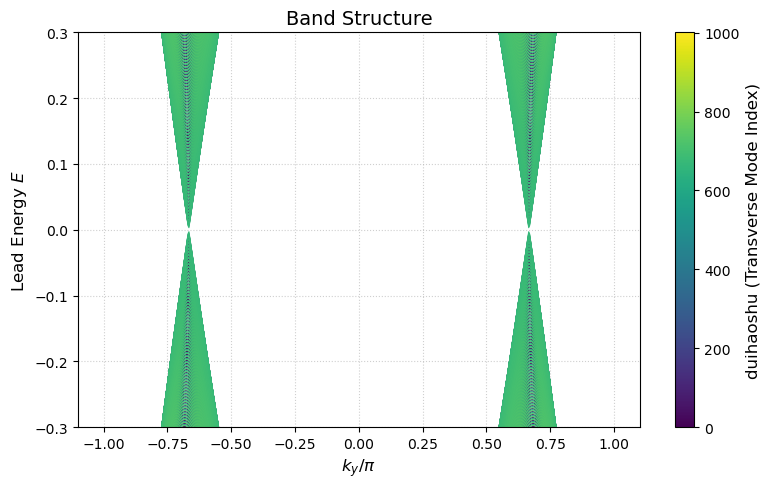

In [144]:
#ky(多个ky)画左边能带

ks1 = np.linspace(-1 * np.pi, 1 * np.pi, 605)

# 2. 你要强行塞进去的两个固定点
extra_points = np.array([-2*9 / (3 * np.pi), 2*9 / (3 * np.pi)])

# 3. 把它们拼接到一起，并从小到大排序！
ks1 = np.sort(np.concatenate((ks1, extra_points)))

def Hk(k, H, T):
    return H + T * np.exp(-1j * k) + T.conj().T * np.exp(1j * k)

plt.figure(figsize=(8, 5))

# ================= 设置色图 (Colormap) =================
cmap = cm.get_cmap('viridis')
# norm 将 duihaoshu 的范围 (0 到 max_duihaoshu) 映射到 0~1 的颜色空间
norm = colors.Normalize(vmin=0, vmax=max_duihaoshu)

# 遍历字典里的所有 duihaoshu 模式
for dhs, mats in tqdm(matrix_dict.items(), desc="Calculating Lead bands"):
    
    H_q = mats["H_q_list"][0] 
    T_21 = mats["T_21"]
    
    energies1 = []
    # 计算当前电极模式的能带
    for k in ks1:

        H_k = Hk(k, H_q, T_21)
        evals1 = np.linalg.eigvalsh(H_k)
        energies1.append(evals1)
        
    energies1 = np.array(energies1)
    
    # 获取当前 duihaoshu 对应的颜色
    color = cmap(norm(dhs))
    
    # 画出当前电极模式的能带
    for i in range(energies1.shape[1]):
        # 使用 plot 画线，linewidth=0.8 既不会太细也不会互相粘连
        plt.plot(ks1/np.pi, energies1[:, i], color=color, linewidth=0.8)

# ================= 设置坐标轴和颜色条 =================
plt.xlabel(r'$k_y/\pi$', fontsize=12)
plt.ylabel('Lead Energy $E$', fontsize=12)
plt.title('Band Structure', fontsize=14) # 改了标题
plt.grid(True, linestyle=':', alpha=0.6)

# 添加右侧颜色条
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([]) 
cbar = plt.colorbar(sm, ax=plt.gca())
cbar.set_label('duihaoshu (Transverse Mode Index)', fontsize=12)
plt.ylim(-0.3, 0.3)
#plt.xlim(-0.3, 0.3)
plt.tight_layout()
plt.show()

C:\Users\taoji\AppData\Local\Temp\ipykernel_25424\1143052372.py:11: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap('viridis')
Calculating Lead bands: 100%|██████████| 300/300 [00:03<00:00, 97.83it/s] 


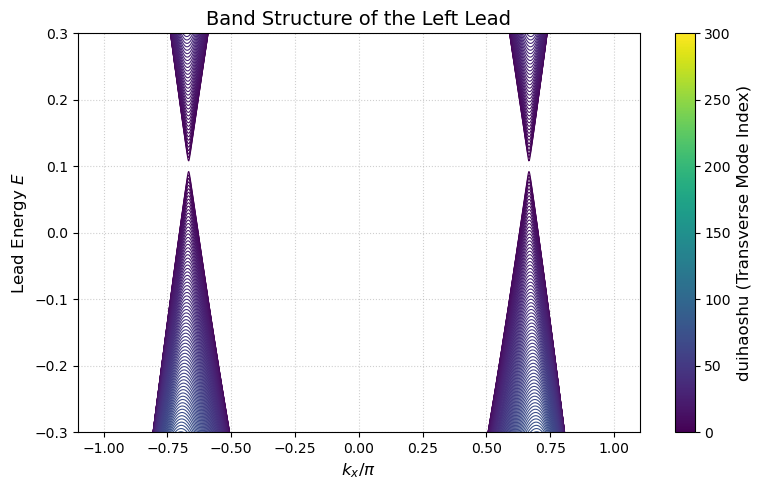

In [133]:
#ky(多个ky)画左边能带
ks1 = np.linspace(-1*np.pi, 1*np.pi, 1001)

def Hk(k, H, T):
    # H(k) = H_onsite + T * exp(-ik) + T.conj().T * exp(ik)
    return H + T * np.exp(-1j * k) + T.conj().T * np.exp(1j * k)

plt.figure(figsize=(8, 5)) # 保持宽比例，给 Colorbar 留位置

# ================= 设置色图 (Colormap) =================
cmap = cm.get_cmap('viridis')
# norm 将 duihaoshu 的范围 (0 到 max_duihaoshu) 映射到 0~1 的颜色空间
norm = colors.Normalize(vmin=0, vmax=max_duihaoshu)

# 遍历字典里的所有 duihaoshu 模式
for dhs, mats in tqdm(matrix_dict.items(), desc="Calculating Lead bands"):
    
    # ================= 核心修改 =================
    # 提取当前 duihaoshu 对应的【左电极】哈密顿量和跃迁矩阵
    H_l = mats["H_l"] 
    T_l = mats["T_l"]
    # ==========================================
    
    energies1 = []
    # 计算当前电极模式的能带
    for k in ks1:
        # 传入电极的 H_l 和 T_l
        H_k = Hk(k, H_l, T_l)
        evals1 = np.linalg.eigvalsh(H_k)
        energies1.append(evals1)
        
    energies1 = np.array(energies1)
    
    # 获取当前 duihaoshu 对应的颜色
    color = cmap(norm(dhs))
    
    # 画出当前电极模式的能带
    for i in range(energies1.shape[1]):
        # 使用 plot 画线，linewidth=0.8 既不会太细也不会互相粘连
        plt.plot(ks1/np.pi, energies1[:, i], color=color, linewidth=0.8)

# ================= 设置坐标轴和颜色条 =================
plt.xlabel(r'$k_x/\pi$', fontsize=12)
plt.ylabel('Lead Energy $E$', fontsize=12)
plt.title('Band Structure of the Left Lead', fontsize=14) # 改了标题
plt.grid(True, linestyle=':', alpha=0.6)

# 添加右侧颜色条
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([]) 
cbar = plt.colorbar(sm, ax=plt.gca())
cbar.set_label('duihaoshu (Transverse Mode Index)', fontsize=12)
plt.ylim(-0.3, 0.3)
#lt.xlim(-0.3, 0.3)
plt.tight_layout()
plt.show()

开始并行计算，总共 1000 个能量点，启动 14 个线程...


Calculating Total Conductance: 100%|██████████| 1000/1000 [00:00<00:00, 2043.84it/s]


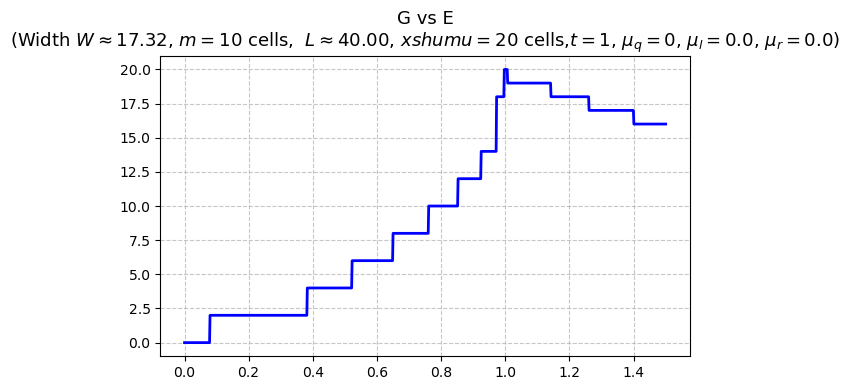

In [88]:
# G vs E xshumu定

E_vals_11 = np.linspace(0, 1.5, 1000)
eta = 1e-6

print(f"开始并行计算，总共 {len(E_vals_11)} 个能量点，启动 14 个线程...")

# 核心：使用 joblib 开启 14 个进程进行并行计算
# tqdm 用于在主进程中显示分配进度
G_total_list = Parallel(n_jobs=14)(
    delayed(calc_G_total_at_E_1)(E_val, matrix_dict, xshumu, eta) 
    for E_val in tqdm(E_vals_11, desc="Calculating Total Conductance")
)

# 将返回的列表转换为 numpy 数组以便画图
G_total_list_11 = np.array(G_total_list)

# ================= 3. 画出物理图像 =================
plt.figure(figsize=(6, 4))

plt.plot(E_vals_11, G_total_list_11 , color='b', linewidth=2)

W_val = 2 * m * b
L_val= 2* xshumu* a
plt.title('G vs E'+ '\n' + 
    rf'(Width $W \approx {W_val:.2f}$, $m={m}$ cells,  $L \approx {L_val:.2f}$, $xshumu={xshumu}$ cells,$t={t}$, $\mu_q={mu_q}$, $\mu_l={mu_l}$, $\mu_r={mu_r}$)', 
    fontsize=13)

plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
#plt.ylim(0,1)

plt.show()

开始并行计算，扫描 100 个长度节点，启动 14 个线程...


Calculating Resistance vs Length: 100%|██████████| 100/100 [00:12<00:00,  8.01it/s]


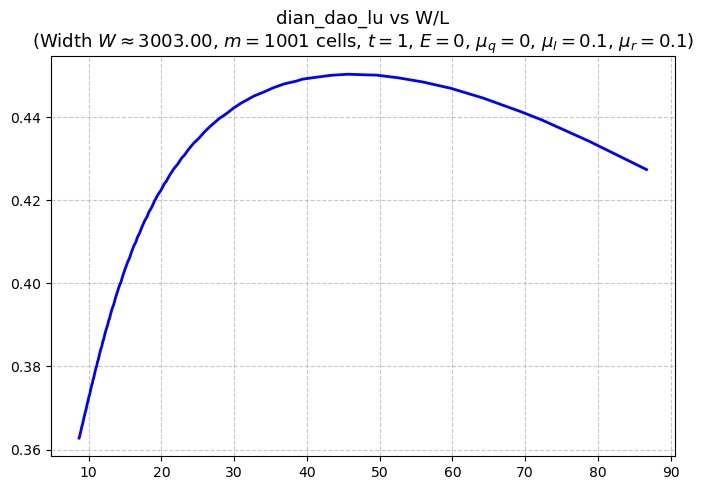

In [158]:
# G vs E xshumu 不定
# ================= 1. 定义单次循环的封装函数 =================
def compute_R_for_length_coherent(xshumu_val, m, b, mu_q, mu_l, mu_r, t, E, eta):
    """
    计算特定长度 xshumu_val 下的相干总电阻（不含退相干探针）。
    """
    # 1. 动态构建该长度下的哈密顿量字典
    matrix_dict_1 = build_matrix_dict(m, b, mu_q, mu_l, mu_r, t, xshumu_val)
    
    # 2. 计算有效电导
    gjvd = calc_G_total_at_E_1(E, matrix_dict_1, xshumu_val, eta)
    
    return  (gjvd*xshumu_val*b/(m*a))

# ================= 2. 参数设置与并行计算 =================
xshumu_set_22 = np.linspace(20, 200, 100).round().astype(int)
E = 0
eta = 1e-6

print(f"开始并行计算，扫描 {len(xshumu_set_22)} 个长度节点，启动 14 个线程...")

# 核心：使用 Parallel 和 delayed 开启 14 线程并发执行
G_total_list_22 = Parallel(n_jobs=14)(
    delayed(compute_R_for_length_coherent)(i, m, b, mu_q, mu_l, mu_r, t, E, eta) 
    for i in tqdm(xshumu_set_22, desc="Calculating Resistance vs Length")
)

# 将返回的列表转换为 numpy 数组以便画图
G_total_list_22 = np.array(G_total_list_22)/(4/np.pi)

# ================= 3. 画出物理图像 =================
plt.figure(figsize=(7, 5))

# 绘制电阻随长度变化的曲线
plt.plot((a*m)/(xshumu_set_22*b), G_total_list_22, color='b', linewidth=2)


# 计算宽度 W，并添加到标题
W_val = m * a
# 注意：如果你这里计算的是纯相干输运，建议把标题的 with Büttiker Probes 删掉，以免日后自己看图时混淆
plt.title('dian_dao_lu vs W/L' + '\n' + 
    rf'(Width $W \approx {W_val:.2f}$, $m={m}$ cells, $t={t}$, $E={E}$, $\mu_q={mu_q}$, $\mu_l={mu_l}$, $\mu_r={mu_r}$)', 
    fontsize=13)

plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
#plt.ylim(-0.1, 1)

plt.show()

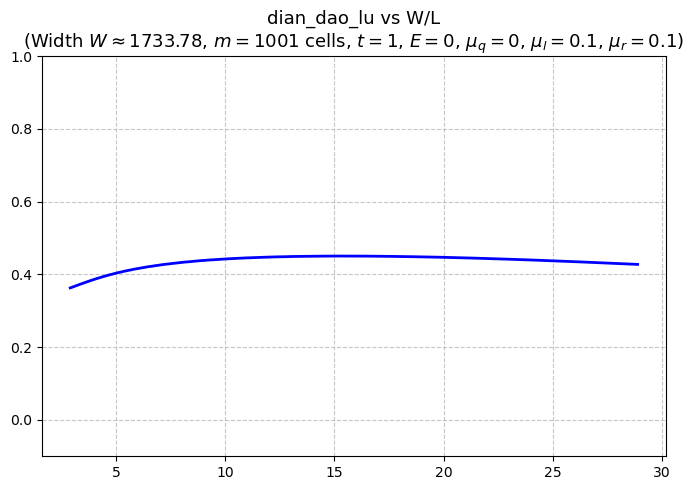

0.7402228396536346 0.7853981633974483


In [159]:
# 将返回的列表转换为 numpy 数组以便画图
G_total_list_22 = np.array(G_total_list_22)#/(4/np.pi)

# ================= 3. 画出物理图像 =================
plt.figure(figsize=(7, 5))

# 绘制电阻随长度变化的曲线
plt.plot((m*b)/(xshumu_set_22*a), G_total_list_22, color='b', linewidth=2)


# 计算宽度 W，并添加到标题
W_val = m * b
# 注意：如果你这里计算的是纯相干输运，建议把标题的 with Büttiker Probes 删掉，以免日后自己看图时混淆
plt.title('dian_dao_lu vs W/L' + '\n' + 
    rf'(Width $W \approx {W_val:.2f}$, $m={m}$ cells, $t={t}$, $E={E}$, $\mu_q={mu_q}$, $\mu_l={mu_l}$, $\mu_r={mu_r}$)', 
    fontsize=13)

plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.ylim(-0.1, 1)

plt.show()
print(G_total_list_22[0]*3/(3**0.5),np.pi/4)